In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax.numpy as jnp
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
import random
import jax
from jax import random
from jax import grad, random,vmap,tree_util
from jax.flatten_util import ravel_pytree

In [2]:
results_heishiro = {
    "MFLD contour": {
        "X_fin": None,
        "KGD_values": None
    },
    "MFLD": {
        "X_fin": None,
        "KGD_values": None
    },
    "Variational Inference": {
        "X_fin": None,
        "KGD_values": None
    },
    "KGD Descent": {
        "X_fin": None,
        "KGD_values": None
    }
}

In [3]:
# import pickle

# with open("results_heishiro.pkl", "wb") as g:
#     pickle.dump(results_heishiro, g)

In [4]:
import pickle

with open("results_heishiro.pkl", "rb") as g:
    results_heishiro_loaded = pickle.load(g)

In [5]:
def kde_mfld(x):
    X = results_heishiro_loaded["MFLD contour"]["X_fin"][:,:2]
    n = X.shape[0]
    h = 10.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

In [43]:
import matplotlib
# font options
font = {
#     'family' : 'normal',
    #'weight' : 'bold',
    'size'   : 22
}
matplotlib.rc('font', **{'family': 'serif', })
plt.rc('font', **font)
plt.rc('lines', linewidth=3, markersize=10)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

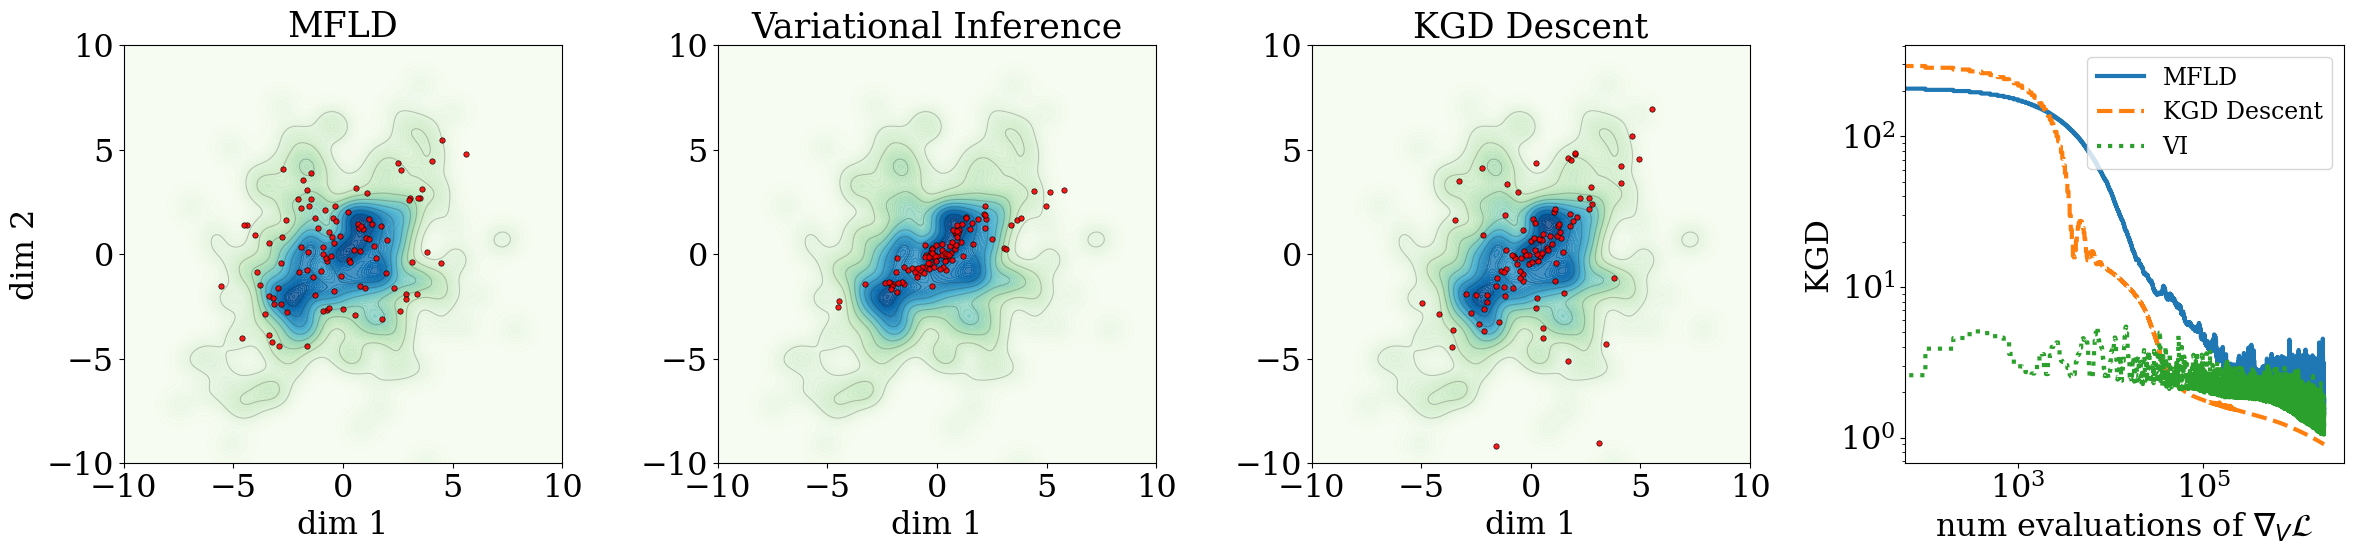

In [45]:
mean = jnp.zeros(2)  
cov = jnp.eye(2) * 2.0  

x = jnp.linspace(-10, 10, 200)
y = jnp.linspace(-10, 10, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])
    
# plt.rcParams.update({
#     'axes.titlesize': 25,        # Taille des titres des axes
#     'axes.labelsize': 23,        # Taille des labels des axes
#     'xtick.labelsize': 23,       # Taille des ticks sur l'axe x
#     'ytick.labelsize': 23,       # Taille des ticks sur l'axe y
#     'legend.fontsize': 17,       # Taille de la légende
#     'figure.titlesize': 25       # Taille du titre global (si utilisé)
# })


fig, axes = plt.subplots(1, 4, figsize=(16*1.5, 4*1.5))

for ind, expe in enumerate(list(results_heishiro_loaded.keys())[1:]):
    
    
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.8     # transparence du fond
    )
    
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
   
    axes[ind].scatter(
        results_heishiro_loaded[expe]["X_fin"][:, 0],
        results_heishiro_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    

    # axes[ind].set_xlim(-12, 12)
    # axes[ind].set_ylim(-12, 12)
    axes[ind].set_xlabel('dim 1')
    axes[ind].set_ylabel('dim 2')
    axes[ind].set_title(expe)
    #axes[ind].legend()
axes[1].set_ylabel("")
axes[2].set_ylabel("")

evaluations_grad_L = jnp.arange(0,len(results_heishiro_loaded["MFLD"]["KGD_values"])) * len(results_heishiro_loaded["MFLD"]["X_fin"])
axes[3].step(evaluations_grad_L,
    results_heishiro_loaded["MFLD"]["KGD_values"], 
    label="MFLD", 
    linestyle='-'
)
axes[3].step(evaluations_grad_L,
    results_heishiro_loaded["KGD Descent"]["KGD_values"], 
    label="KGD Descent", 
    linestyle='--'
)
axes[3].step(evaluations_grad_L,
    results_heishiro_loaded["Variational Inference"]["KGD_values"], 
    label="VI", 
    linestyle=':'
)
axes[3].legend()
axes[3].set_xscale("log")
axes[3].set_yscale("log")
axes[3].set_xlabel(r"num evaluations of $\nabla_V \mathcal{L}$")
axes[3].set_ylabel("KGD")
#plt.title("KGD")
plt.tight_layout()

plt.savefig("fig2.png", format="png")


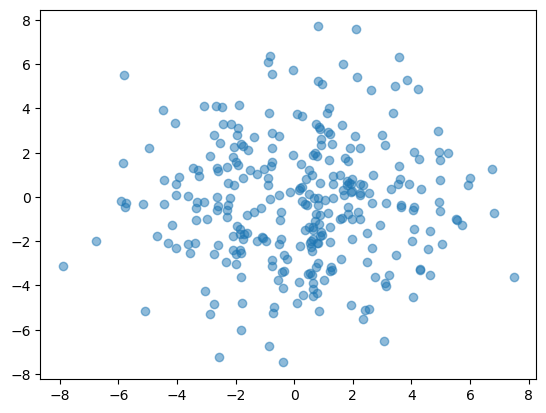

In [8]:
plt.scatter(results_heishiro_loaded["MFLD contour"]["X_fin"][:, 2], results_heishiro_loaded["MFLD contour"]["X_fin"][:, 3], label="MFLD contour", alpha=0.5)